# Synthetic biomarker benchmark — the shapes and what they settle

This notebook is the specification. Every shape below has values that follow from its geometry, and
those values are what a biomarker implementation is measured against — not another implementation's
opinion, and not a human's tracing.

**Why shapes at all.** A biomarker's name is not its definition: "tortuosity" names at least three
incompatible formulas, and papers usually report the name and omit the choice. Comparing two
programs tells you they differ without telling you which is right. A straight vessel has tortuosity
exactly 1, and that settles it.

**What it catches that a dataset cannot:** a factor of two in a curvature formula, a centreline
extractor that counts pixel steps where it should measure arc length, an arteriovenous ratio
computed from arteries alone, a measurement that moves when the vessel is rotated.

Rotations are generated by the run, not shown here — this notebook is the shapes at rest.

How the benchmark is configured: [biomarker-synthetic-docs.md](../docs/benchmarks/biomarker-synthetic-docs.md).
The rules the shapes follow: `.claude/skills/build-benchmark/biomarker-synthetic.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    """The repository, found rather than assumed."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))

from benchmarks.shapes import library  # noqa: E402

#: The grid these pictures are drawn at. The run uses several; the shapes are the same at each.
SIDE = 1024

#: Microns per pixel. A synthetic shape has no camera, so this is a stated convention rather than a
#: measurement — but it has to be stated, because Hubbard's central retinal equivalents carry
#: constants fitted in microns and mean nothing without one. Ten is a plausible fundus resolution.
UM_PER_PX = 10.0

built = {
    name: library.build(name, side=SIDE, um_per_px=UM_PER_PX) for name in library.SHAPES
}
print(f"{len(built)} shapes at {SIDE}², {UM_PER_PX} µm per pixel: {', '.join(built)}")

7 shapes at 1024², 10.0 µm per pixel: straight, arc, sinusoid, bifurcation, disjoint, artery-vein-pair, disc-spokes


## 1. The shapes

Each is drawn from a centreline in continuous coordinates and rasterised once — never drawn small
and enlarged, and never rotated as a picture, because resampling a structure a few pixels wide
destroys it.

**Arteries are red, veins are blue**, the field of view is the dark circle, and the optic disc is
the ring — to the right of centre, where a fundus camera puts it, and far enough in that the ring
the central retinal equivalents are measured over stays inside the retina at every rotation. A shape that tests a measurement over the vessels as one class puts them all in the
artery mask and leaves the vein mask absent — an adapter then forms the union of what it was
given, which is the same derivation the artery/vein benchmark applies to every model.

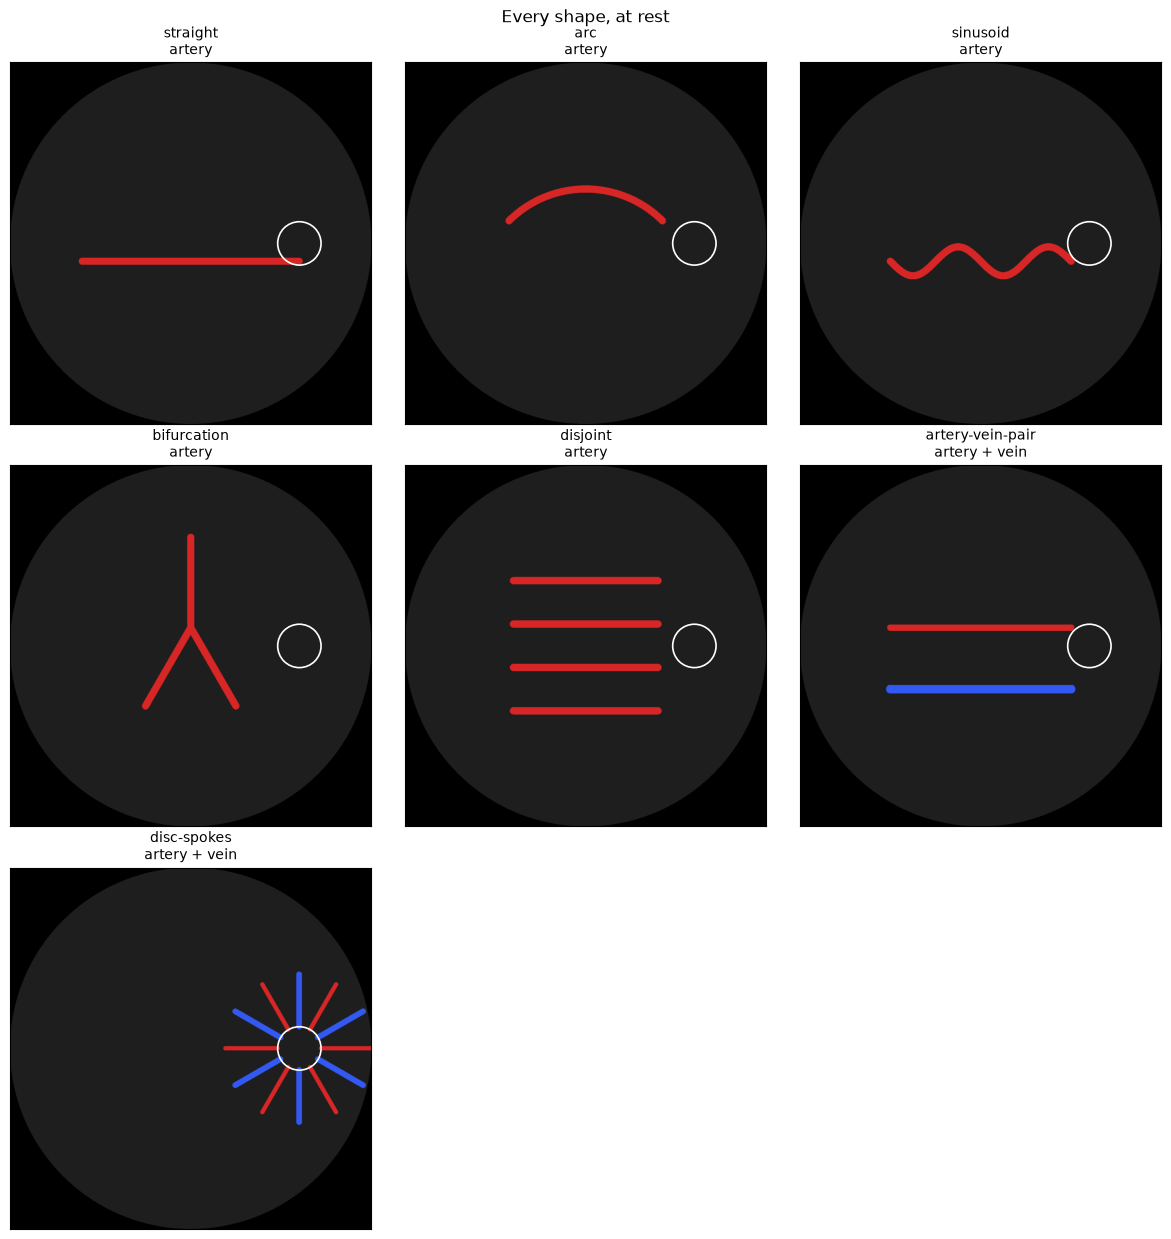

In [2]:
def picture(shape, axis) -> None:
    """One shape as an adapter receives it: two classes, a field of view, and where the disc is."""
    canvas = np.zeros((shape.side, shape.side, 3))
    canvas[shape.fov] = 0.12
    if shape.artery is not None:
        canvas[shape.artery] = (0.85, 0.15, 0.15)
    if shape.vein is not None:
        canvas[shape.vein] = (0.20, 0.35, 0.95)
    axis.imshow(canvas)
    x, y, radius = shape.disc
    axis.add_patch(plt.Circle((x, y), radius, fill=False, color="white", linewidth=1.2))
    classes = " + ".join(
        name for name, mask in (("artery", shape.artery), ("vein", shape.vein)) if mask is not None
    )
    axis.set_title(f"{shape.name}\n{classes}", fontsize=10)
    axis.set_xticks([])
    axis.set_yticks([])


fig, axes = plt.subplots(3, 3, figsize=(12, 12.6))
for axis in axes.ravel()[len(built):]:
    axis.set_visible(False)
for axis, shape in zip(axes.ravel(), built.values()):
    picture(shape, axis)
fig.suptitle("Every shape, at rest", fontsize=12)
fig.tight_layout()

## 2. What each shape settles

One row per quantity, one column per shape, keyed as `biomarker/variant` after the catalogue in
`docs/biomarkers/` — so a number an implementation returns is compared with the right definition
rather than with whichever happens to share its name.

An empty cell means the shape says nothing about that quantity, which is not the same as zero.

In [3]:
theory = pd.DataFrame({name: shape.theory for name, shape in built.items()}).sort_index()
theory.index.name = "biomarker / variant"
theory.round(4).style.set_table_styles(
    [
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
        {"selector": "th.index_name", "props": [("text-align", "left")]},
    ]
)

,straight,arc,sinusoid,bifurcation,disjoint,artery-vein-pair,disc-spokes
biomarker / variant,,,,,,,
avr/hubbard/both,nan,nan,nan,nan,nan,nan,0.765100
avr/knudtson/both,nan,nan,nan,nan,nan,0.750000,0.613500
avr/ratio-of-calibres/both,nan,nan,nan,nan,nan,0.750000,0.750000
bifurcation-angle/between-daughters/artery,nan,nan,nan,60.000000,nan,nan,nan
central-retinal-equivalents/hubbard/artery,nan,nan,nan,nan,nan,nan,233.168700
central-retinal-equivalents/hubbard/vein,nan,nan,nan,nan,nan,nan,304.761700
central-retinal-equivalents/knudtson/artery,nan,nan,nan,nan,nan,18.432000,21.484700
central-retinal-equivalents/knudtson/vein,nan,nan,nan,nan,nan,24.576000,35.022600
junction-counts/components/vessels,1.000000,nan,nan,1.000000,4.000000,nan,12.000000


## 3. The derivations

Each value above follows from the geometry, and each is stated here so that a reader can disagree
with the arithmetic rather than with the code.

### 3.1 Straight vessel

Tortuosity is **exactly 1** under any arc-over-chord definition, because the arc *is* the chord.
Total curvature is **exactly 0**. The calibre is the width it was drawn at. Its area is the width
times the length, plus a disc of that width for the two rounded ends — the two-dimensional tube
formula, which holds for any curve that does not cross itself.

This is the shape that catches the most basic error available: an implementation whose tortuosity
is not 1 here is not computing tortuosity.

### 3.2 Circular arc

Curvature is **exactly 1/r** everywhere. Arc length is `rθ`, the chord is `2r sin(θ/2)`, so

$$\tau_1 = \frac{r\theta}{2r\sin(\theta/2)} = \frac{\theta}{2\sin(\theta/2)}$$

in which **`r` cancels**. That is the useful part: τ1 depends on how far the vessel bends and not at
all on how large it is, so an implementation whose τ1 changes with the radius is computing
something else. Total curvature is `θ`; total squared curvature is `θ/r`.

### 3.3 Sinusoid

Its arc length is an elliptic integral with no elementary closed form, so the theory *is* the
integral — evaluated over 200,001 points, which is exact to far more places than any implementation
will reach. The same integration gives `∫κ ds` and `∫κ² ds`, with

$$\kappa = \frac{|y''|}{(1 + y'^2)^{3/2}}$$

A curve with curvature that varies along its length is what separates an implementation that
integrates properly from one that averages a few sampled points.

### 3.4 Bifurcation

Symmetric, so the angle between the daughters is exactly the angle asked for and neither daughter
is the trunk. One junction, three endpoints, one connected component.

### 3.5 Parallel vessels that never meet

No junctions, and as many components as there are lines. A skeletoniser that joins them, or a
junction counter that finds a crossing where two vessels merely pass near one another, says so here
and nowhere else.

### 3.6 Artery beside vein

Two vessels of constant widths `wa` and `wv`, far from the disc. Their ratio of calibres is
**exactly `wa / wv`**.

What this shape deliberately does **not** promise is a central retinal equivalent. Those are
measured over a ring around the optic disc, and vessels that never cross that ring cannot produce
one — so an implementation that returns a CRAE here is measuring something it was not given, which
is a finding rather than a value. That was wrong in the first version of this notebook, where the
shape claimed `CRAE = wa`.

### 3.7 Spokes from the disc

The shape the central retinal equivalents actually need. Six arteries and six veins radiate from
the disc margin past three disc radii, so every one of them crosses the annulus between **two and
three disc radii** that PVBM builds as zone C minus zone B — the region
[central-retinal-equivalents.md](../docs/biomarkers/central-retinal-equivalents.md) §5 records, and
the one the classical convention states in disc *diameters*, a factor-of-two trap when reading code.

All arteries share one width and all veins share another, which makes the theory unambiguous:
Knudtson's recursion pairs the widest vessel with the narrowest, the next widest with the next
narrowest, and combines each pair as `k·√(w₁² + w₂²)` — `k` being 0.88 for arterioles and 0.95 for
venules — repeating until one number is left. With six equal widths **every pairing order gives the
same answer**, so the shape tests the formula and the region rather than an implementation's
sorting convention. A shape with unequal widths would test the convention and have no single
correct answer to test it against.

The two classes alternate around the disc so that neither is bunched on one side, where a
temporal-only or half-ring convention would miss it.

## 4. A rasterised shape is not the shape

The theory describes a continuous curve; an implementation sees pixels. The difference is real and
is nobody's bug — and it is why this benchmark renders every shape at several resolutions rather
than judging at one.

Below: the area actually drawn, against the area the geometry requires, as the grid refines.

**Expect a sawtooth, not a smooth curve.** What separates the two is at most one row of pixels along
the vessel, and whether that row is taken depends on where the centreline falls between pixel
centres. The error can therefore rise between two resolutions with nothing wrong. Read the trend
across four, never the step between two.

In [4]:
rows = []
for side in (256, 512, 1024, 2048):
    shape = library.build("straight", side=side, um_per_px=UM_PER_PX)
    drawn = float(shape.artery.sum())
    rows.append(
        {
            "side": side,
            "width, px": round(shape.parameters["width"], 1),
            "area drawn": drawn,
            "area geometry requires": shape.theory["vessel-area-and-length/area/artery"],
            "relative difference": drawn / shape.theory["vessel-area-and-length/area/artery"] - 1.0,
            "one row of pixels would be": 1.0 / shape.parameters["width"],
        }
    )
pd.DataFrame(rows).set_index("side").round(4)

,"width, px",area drawn,area geometry requires,relative difference,one row of pixels would be
side,,,,,
256,5.1,788.0,807.0207,-0.0236,0.1953
512,10.2,3464.0,3228.0830,0.0731,0.0977
1024,20.5,12610.0,12912.3319,-0.0234,0.0488
2048,41.0,51698.0,51649.3275,0.0009,0.0244


## 5. The one place the scale matters

Nothing above depends on how many microns a pixel is worth: a tortuosity is a ratio, a junction is
a junction, and a calibre in pixels is a calibre in pixels. **The central retinal equivalents are
the exception**, and only one of the two variants.

- **Knudtson** combines each pair as `k·√(w₁² + w₂²)` with `k` = 0.88 for arterioles and 0.95 for
  venules. Purely multiplicative, so it is scale-free: compute it on pixel widths and convert
  afterwards if you like.
- **Hubbard** combines them as `√(a·w₁² + b·w₂² + c·w₁w₂ + d)` with coefficients fitted in
  **microns** — and the additive `d`, −10.76 for arterioles and +450.05 for venules, **does not
  scale**. A Hubbard value computed on pixel widths is not a rescaled Hubbard value; it is a
  different number wearing the same name.

So the table below is the same shape measured at three resolutions. Knudtson's equivalent does not
move. Hubbard's does, and the arteriovenous ratios built from them move with them.

One more thing the shapes make visible: **the three arteriovenous ratios are three different
numbers on the same vessels** — the plain ratio of calibres, Knudtson's, and Hubbard's. They can
even coincide at a particular scale, which is a coincidence of the constants rather than agreement
of definitions; what proves them different is that only some of them move when the scale does.

In [5]:
rows = []
for scale in (5.0, 10.0, 20.0):
    for name in ("artery-vein-pair", "disc-spokes"):
        shape = library.build(name, side=SIDE, um_per_px=scale)
        rows.append(
            {
                "shape": name,
                "µm per pixel": scale,
                "CRAE Knudtson, px": shape.theory.get("central-retinal-equivalents/knudtson/artery"),
                "CRVE Knudtson, px": shape.theory.get("central-retinal-equivalents/knudtson/vein"),
                "CRAE Hubbard, µm": shape.theory.get("central-retinal-equivalents/hubbard/artery"),
                "CRVE Hubbard, µm": shape.theory.get("central-retinal-equivalents/hubbard/vein"),
                "AVR, calibres": shape.theory.get("avr/ratio-of-calibres/both"),
                "AVR, Knudtson": shape.theory.get("avr/knudtson/both"),
                "AVR, Hubbard": shape.theory.get("avr/hubbard/both"),
            }
        )
# An empty Hubbard cell on the pair is the point of that shape: one artery and one vein cross the
# ring, Knudtson's recursion passes a lone vessel through untouched, and Hubbard's combines a pair
# and so has nothing to combine. An implementation must decline there rather than invent a vessel.
pd.DataFrame(rows).set_index(["shape", "µm per pixel"]).round(3)

,,"CRAE Knudtson, px","CRVE Knudtson, px","CRAE Hubbard, µm","CRVE Hubbard, µm","AVR, calibres","AVR, Knudtson","AVR, Hubbard"
shape,µm per pixel,,,,,,,
artery-vein-pair,5.0,18.432,24.576,NaN,NaN,0.75,0.750,NaN
disc-spokes,5.0,21.485,35.023,116.447,156.537,0.75,0.613,0.744
artery-vein-pair,10.0,18.432,24.576,NaN,NaN,0.75,0.750,NaN
disc-spokes,10.0,21.485,35.023,233.169,304.762,0.75,0.613,0.765
artery-vein-pair,20.0,18.432,24.576,NaN,NaN,0.75,0.750,NaN
disc-spokes,20.0,21.485,35.023,466.474,605.296,0.75,0.613,0.771


## 6. What this benchmark does not test

- **Cup-to-disc ratio.** An adapter is handed the disc as a centre and a radius and is given no
  cup, so the ratio cannot be formed. It is measured against ophthalmologists' own outlines in the
  [disc benchmark](../docs/benchmarks/disc-results.md) instead.
- **Anything anchored to the fovea** — the disc-fovea distance, and the temporal angle — because a
  synthetic shape has no macula and inventing one would make the answer a property of the fixture.
- **Vessel tracing**, which is a step rather than a number.
- **Whether an implementation works on a photograph.** A program that measures a synthetic vessel
  exactly may still fail on a segmentation of a real eye, which is the next benchmark's question.